## package and plot style

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Darts
from darts import TimeSeries, metrics
from darts.models import SKLearnClassifierModel, XGBClassifierModel
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import MinMaxScaler

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix as sk_confusion_matrix,
    roc_auc_score, roc_curve
)

# SHAP
import shap

COLORS = {
    'IHSG': '#2E7D32', 'IHSG_light': '#4CAF50',
    'M2_YoY': '#1976D2', 'USDIDR': '#7B1FA2',
    'BI_Rate': '#F57C00', 'NPL_Ratio': '#C2185B',
    'up': '#2E7D32', 'down': '#D32F2F',
    'train': '#2E7D32', 'actual': '#1976D2', 'predicted': '#D32F2F',
}

In [ ]:
url = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/model1-new.csv'
df = pd.read_csv(url)
df_clean = df.copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y') + pd.offsets.MonthEnd(0)
pct_columns = ['BI Interest Rate', 'npl_ratio']
for col in pct_columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].str.replace('%', '').astype(float)


df_clean = df_clean.sort_values('Date').reset_index(drop=True)
df_clean.columns = ['Date', 'IHSG', 'Inflation_YoY', 'M2_YoY', 'USDIDR', 
                     'BI_Rate', 'NPL_Ratio', 'M2_MoM']

In [7]:
df_clean

,Date,IHSG,Inflation_YoY,M2_YoY,USDIDR,BI_Rate,NPL_Ratio,M2_MoM
0,2014-12-31,5226.950,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-31,5289.404,6.96,14.31,12755.0,7.75,2.37,0.04
2,2015-02-28,5450.294,6.29,16.04,12928.0,7.50,2.43,1.04
3,2015-03-31,5518.675,6.38,16.26,13075.0,7.50,2.40,0.67
4,2015-04-30,5086.425,6.79,14.88,12964.0,7.50,2.48,0.69
...,...,...,...,...,...,...,...,...
117,2024-09-30,7527.929,1.84,7.19,15140.0,6.00,2.21,0.81
118,2024-10-31,7574.019,1.71,6.77,15697.0,6.00,2.20,0.38
119,2024-11-30,7114.266,1.55,6.53,15845.0,6.00,2.19,0.57
120,2024-12-31,7079.905,1.57,4.76,16102.0,6.00,2.08,1.23


In [8]:
# select variable for models
df_model = df_clean[['Date', 'IHSG', 'M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']].copy()

# Create target: IHSG direction (1 = naik, 0 = turun)
df_model['IHSG_Return'] = df_model['IHSG'].pct_change() * 100
df_model['IHSG_Direction'] = (df_model['IHSG_Return'] > 0).astype(float)

# Drop first row (NaN from pct_change)
df_model = df_model.dropna().reset_index(drop=True)

print(f"Date Range: {df_model['Date'].min()} to {df_model['Date'].max()}")
print(f"Total Months: {len(df_model)}")
print(f"\nTarget Distribution:")
print(f"  Naik  (1): {int(df_model['IHSG_Direction'].sum())} bulan ({df_model['IHSG_Direction'].mean()*100:.1f}%)")
print(f"  Turun (0): {int((1-df_model['IHSG_Direction']).sum())} bulan ({(1-df_model['IHSG_Direction'].mean())*100:.1f}%)")
print(f"\nCovariates: M2_YoY, USDIDR, BI_Rate, NPL_Ratio")

Date Range: 2015-01-31 00:00:00 to 2025-01-31 00:00:00
Total Months: 121

Target Distribution:
  Naik  (1): 71 bulan (58.7%)
  Turun (0): 50 bulan (41.3%)

Covariates: M2_YoY, USDIDR, BI_Rate, NPL_Ratio


In [12]:
df_model[['IHSG', 'IHSG_Return', 'M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']].describe().round(2)

,IHSG,IHSG_Return,M2_YoY,USDIDR,BI_Rate,NPL_Ratio
count,121.00,121.00,121.00,121.00,121.00,121.00
mean,6077.38,0.32,8.81,14363.80,5.25,2.77
std,850.61,3.63,2.74,895.79,1.24,0.32
min,4223.91,-16.76,3.35,12755.00,3.50,2.08
25%,5386.69,-0.89,6.77,13655.00,4.25,2.52
50%,6056.12,0.57,8.18,14273.00,5.25,2.76
75%,6843.24,2.55,10.53,14903.00,6.00,3.05
max,7670.73,9.44,16.26,16375.00,7.75,3.35


In [13]:
# Return by direction
print("\n--- IHSG Return by Direction ---")
for direction in [1, 0]:
    subset = df_model[df_model['IHSG_Direction'] == direction]['IHSG_Return']
    label = "Naik" if direction == 1 else "Turun"
    print(f"  {label}: n={len(subset)}, mean={subset.mean():.2f}%, std={subset.std():.2f}%, "
          f"min={subset.min():.2f}%, max={subset.max():.2f}%")


--- IHSG Return by Direction ---
  Naik: n=71, mean=2.54%, std=1.97%, min=0.06%, max=9.44%
  Turun: n=50, mean=-2.82%, std=3.08%, min=-16.76%, max=-0.05%


In [14]:
# Correlation
print("\n--- Correlation with IHSG Direction ---")
for col in ['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']:
    corr = df_model[col].corr(df_model['IHSG_Direction'])
    print(f"  {col:15s}: {corr:+.4f}")


--- Correlation with IHSG Direction ---
  M2_YoY         : +0.1431
  USDIDR         : -0.1740
  BI_Rate        : -0.1164
  NPL_Ratio      : +0.1548


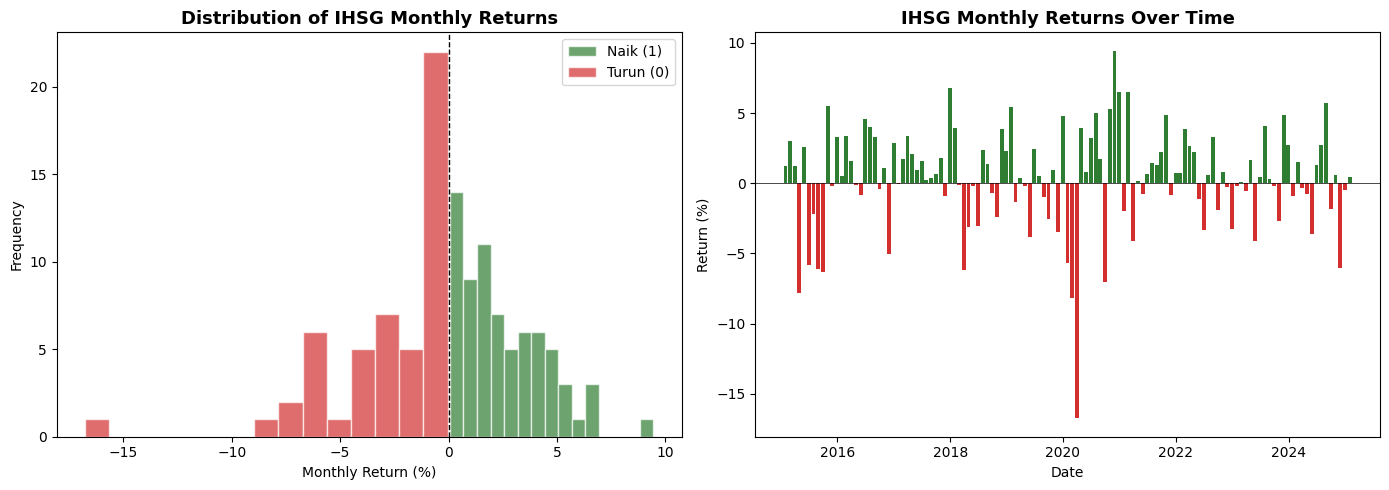

✅ Saved: classification_eda.png


In [15]:
# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model[df_model['IHSG_Direction']==1]['IHSG_Return'], bins=15,
             alpha=0.7, color=COLORS['up'], label='Naik (1)', edgecolor='white')
axes[0].hist(df_model[df_model['IHSG_Direction']==0]['IHSG_Return'], bins=15,
             alpha=0.7, color=COLORS['down'], label='Turun (0)', edgecolor='white')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of IHSG Monthly Returns', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

colors_ts = [COLORS['up'] if d == 1 else COLORS['down'] for d in df_model['IHSG_Direction']]
axes[1].bar(df_model['Date'], df_model['IHSG_Return'], color=colors_ts, width=25)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('IHSG Monthly Returns Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.savefig('classification_eda.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_eda.png")

In [16]:
df_model

,Date,IHSG,M2_YoY,USDIDR,BI_Rate,NPL_Ratio,IHSG_Return,IHSG_Direction
0,2015-01-31,5289.404,14.31,12755.0,7.75,2.37,1.194846,1.0
1,2015-02-28,5450.294,16.04,12928.0,7.50,2.43,3.041742,1.0
2,2015-03-31,5518.675,16.26,13075.0,7.50,2.40,1.254630,1.0
3,2015-04-30,5086.425,14.88,12964.0,7.50,2.48,-7.832496,0.0
4,2015-05-31,5216.379,13.42,13225.0,7.50,2.58,2.554918,1.0
...,...,...,...,...,...,...,...,...
116,2024-09-30,7527.929,7.19,15140.0,6.00,2.21,-1.861673,0.0
117,2024-10-31,7574.019,6.77,15697.0,6.00,2.20,0.612253,1.0
118,2024-11-30,7114.266,6.53,15845.0,6.00,2.19,-6.070133,0.0
119,2024-12-31,7079.905,4.76,16102.0,6.00,2.08,-0.482987,0.0


In [17]:
# target
target_series = TimeSeries.from_dataframe(
    df_model, time_col='Date', value_cols='IHSG_Direction', freq='ME'
)

# Covariates
covar_series = TimeSeries.from_dataframe(
    df_model, time_col='Date', 
    value_cols=['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio'], freq='ME'
)

# Train/Test Split 80:20
split_point = int(len(target_series) * 0.8)
target_train = target_series[:split_point]
target_test = target_series[split_point:]

# Scale covariates only (target is binary)
scaler_covar = Scaler(MinMaxScaler(feature_range=(-1, 1)))
covar_train_scaled = scaler_covar.fit_transform(covar_series[:split_point])
covar_test_scaled = scaler_covar.transform(covar_series[split_point:])
covar_full_scaled = covar_train_scaled.append(covar_test_scaled)

print(f"Train: {target_train.start_time()} → {target_train.end_time()} ({len(target_train)} obs)")
print(f"Test:  {target_test.start_time()} → {target_test.end_time()} ({len(target_test)} obs)")

train_vals = target_train.values().flatten()
test_vals = target_test.values().flatten()
print(f"\nTrain distribution: Naik={int(train_vals.sum())} ({train_vals.mean()*100:.1f}%), "
      f"Turun={int(len(train_vals)-train_vals.sum())} ({(1-train_vals.mean())*100:.1f}%)")
print(f"Test distribution:  Naik={int(test_vals.sum())} ({test_vals.mean()*100:.1f}%), "
      f"Turun={int(len(test_vals)-test_vals.sum())} ({(1-test_vals.mean())*100:.1f}%)")
print(f"\n✓ Covariates scaled (fit on train only, no leakage)")

Train: 2015-01-31 00:00:00 → 2022-12-31 00:00:00 (96 obs)
Test:  2023-01-31 00:00:00 → 2025-01-31 00:00:00 (25 obs)

Train distribution: Naik=58 (60.4%), Turun=38 (39.6%)
Test distribution:  Naik=13 (52.0%), Turun=12 (48.0%)

✓ Covariates scaled (fit on train only, no leakage)


In [19]:
from itertools import product as iterproduct

rf_sklearn_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True, False],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

rf_instances = []
for vals in iterproduct(*rf_sklearn_grid.values()):
    params = dict(zip(rf_sklearn_grid.keys(), vals))
    rf_instances.append(
        RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    )

print(f"sklearn RF variants generated: {len(rf_instances)}")
for k, v in rf_sklearn_grid.items():
    print(f"  {k}: {v}")

# Darts-level param grid
param_grid_rf = {
    'lags': [1, 3, 6, 12],
    'lags_past_covariates': [1, 3, 6, 12],
    'output_chunk_length': [1],
    'model': rf_instances,
}

total_combos = 4 * 4 * 1 * len(rf_instances)
n_random = 200
print(f"\nDarts lags: [1, 3, 6, 12] × [1, 3, 6, 12] = 16 lag combinations")
print(f"Total combinations: 16 × {len(rf_instances)} = {total_combos:,}")
print(f"Random samples: {n_random}")
print(f"\nRunning Darts native gridsearch (metric=accuracy)...")

best_rf_model, best_rf_params, best_rf_score = SKLearnClassifierModel.gridsearch(
    parameters=param_grid_rf,
    series=target_train,
    past_covariates=covar_full_scaled,
    val_series=target_test,
    metric=metrics.accuracy,
    verbose=True,
    n_jobs=1,
    n_random_samples=n_random,
    show_warnings=False,
)

# Extract best sklearn model
rf_best_sklearn = best_rf_params.get('model', rf_instances[0])

print(f"\n{'=' * 60}")
print(f"RF GRIDSEARCH RESULTS")
print(f"{'=' * 60}")
print(f"Best Accuracy: {best_rf_score:.4f} ({best_rf_score*100:.1f}%)")
print(f"\nBest Hyperparameters:")
print(f"  [Darts-level]")
print(f"    lags: {best_rf_params.get('lags')}")
print(f"    lags_past_covariates: {best_rf_params.get('lags_past_covariates')}")
print(f"    output_chunk_length: {best_rf_params.get('output_chunk_length', 1)}")
print(f"  [sklearn-level]")
print(f"    n_estimators: {rf_best_sklearn.n_estimators}")
print(f"    max_depth: {rf_best_sklearn.max_depth}")
print(f"    max_features: {rf_best_sklearn.max_features}")
print(f"    bootstrap: {rf_best_sklearn.bootstrap}")
print(f"    min_samples_split: {rf_best_sklearn.min_samples_split}")
print(f"    min_samples_leaf: {rf_best_sklearn.min_samples_leaf}")
print(f"    criterion: {rf_best_sklearn.criterion}")

rf_params_save = {
    'lags': best_rf_params.get('lags'),
    'lags_past_covariates': best_rf_params.get('lags_past_covariates'),
    'output_chunk_length': best_rf_params.get('output_chunk_length', 1),
    'n_estimators': rf_best_sklearn.n_estimators,
    'max_depth': str(rf_best_sklearn.max_depth),
    'max_features': str(rf_best_sklearn.max_features),
    'bootstrap': rf_best_sklearn.bootstrap,
    'min_samples_split': rf_best_sklearn.min_samples_split,
    'min_samples_leaf': rf_best_sklearn.min_samples_leaf,
    'criterion': rf_best_sklearn.criterion,
}
with open('rf_classifier_best_params.json', 'w') as f:
    json.dump(rf_params_save, f, indent=2)
print("✓ Saved: rf_classifier_best_params.json")


sklearn RF variants generated: 1296
  n_estimators: [50, 100, 200]
  max_depth: [3, 5, 7, None]
  max_features: [None, 'sqrt', 'log2']
  bootstrap: [True, False]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  criterion: ['gini', 'entropy']

Darts lags: [1, 3, 6, 12] × [1, 3, 6, 12] = 16 lag combinations
Total combinations: 16 × 1296 = 20,736
Random samples: 200

Running Darts native gridsearch (metric=accuracy)...


gridsearch:   0%|          | 0/200 [00:00<?, ?it/s]

This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: us


RF GRIDSEARCH RESULTS
Best Accuracy: 0.3200 (32.0%)

Best Hyperparameters:
  [Darts-level]
    lags: 3
    lags_past_covariates: 1
    output_chunk_length: 1
  [sklearn-level]
    n_estimators: 100
    max_depth: 7
    max_features: None
    bootstrap: True
    min_samples_split: 5
    min_samples_leaf: 4
    criterion: gini
✓ Saved: rf_classifier_best_params.json


In [20]:
param_grid_xgb = {
    'lags': [1, 3, 6, 12],
    'lags_past_covariates': [1, 3, 6, 12],
    'output_chunk_length': [1],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

total_xgb = 1
for v in param_grid_xgb.values():
    total_xgb *= len(v)
n_random_xgb = 200

print(f"Parameter space:")
for k, v in param_grid_xgb.items():
    print(f"  {k}: {v}")
print(f"\nTotal combinations: {total_xgb:,}")
print(f"Random samples: {n_random_xgb}")
print(f"\nRunning Darts native gridsearch (metric=accuracy)...")

best_xgb_model, best_xgb_params, best_xgb_score = XGBClassifierModel.gridsearch(
    parameters=param_grid_xgb,
    series=target_train,
    past_covariates=covar_full_scaled,
    val_series=target_test,
    metric=metrics.accuracy,
    verbose=True,
    n_jobs=1,
    n_random_samples=n_random_xgb,
    show_warnings=False,
)

print(f"\n{'=' * 60}")
print(f"XGBOOST GRIDSEARCH RESULTS")
print(f"{'=' * 60}")
print(f"Best Accuracy: {best_xgb_score:.4f} ({best_xgb_score*100:.1f}%)")
print(f"\nBest Hyperparameters:")
for k, v in best_xgb_params.items():
    print(f"  {k}: {v}")

xgb_params_save = {k: (str(v) if v is None else v) for k, v in best_xgb_params.items()}
with open('xgb_classifier_best_params.json', 'w') as f:
    json.dump(xgb_params_save, f, indent=2)
print("✓ Saved: xgb_classifier_best_params.json")

Parameter space:
  lags: [1, 3, 6, 12]
  lags_past_covariates: [1, 3, 6, 12]
  output_chunk_length: [1]
  n_estimators: [50, 100, 200]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.05, 0.1]
  subsample: [0.8, 1.0]
  colsample_bytree: [0.8, 1.0]

Total combinations: 1,728
Random samples: 200

Running Darts native gridsearch (metric=accuracy)...


gridsearch:   0%|          | 0/200 [00:00<?, ?it/s]

This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: us


XGBOOST GRIDSEARCH RESULTS
Best Accuracy: 0.3200 (32.0%)

Best Hyperparameters:
  lags: 3
  lags_past_covariates: 3
  output_chunk_length: 1
  n_estimators: 200
  max_depth: 7
  learning_rate: 0.1
  subsample: 1.0
  colsample_bytree: 0.8
✓ Saved: xgb_classifier_best_params.json


In [22]:
print("\n" + "=" * 70)
print("CELL 7: HISTORICAL FORECASTS & EVALUATION")
print("=" * 70)

hfc_common = {
    'series': target_series,
    'past_covariates': covar_full_scaled,
    'start': target_test.start_time(),
    'forecast_horizon': 1,
    'stride': 1,
    'retrain': False,
    'last_points_only': True,
    'show_warnings': False,
}

# Fit best models on training data first
print("Fitting best models on training data...")
best_rf_model.fit(series=target_train, past_covariates=covar_full_scaled)
best_xgb_model.fit(series=target_train, past_covariates=covar_full_scaled)
print("✓ Models fitted")

print("\nGenerating historical forecasts (1-step-ahead)...")
rf_preds = best_rf_model.historical_forecasts(**hfc_common)
print(f"  RF:  {len(rf_preds)} predictions ({rf_preds.start_time()} → {rf_preds.end_time()})")

xgb_preds = best_xgb_model.historical_forecasts(**hfc_common)
print(f"  XGB: {len(xgb_preds)} predictions ({xgb_preds.start_time()} → {xgb_preds.end_time()})")

# --- Darts Backtest Metrics ---
metric_list = [metrics.accuracy, metrics.precision, metrics.recall, metrics.f1]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

print(f"\n{'─' * 55}")
print("RANDOM FOREST — Classification Metrics")
print(f"{'─' * 55}")

rf_backtest = best_rf_model.backtest(
    historical_forecasts=rf_preds, **hfc_common, metric=metric_list,
)
rf_metrics_dict = dict(zip(metric_names, rf_backtest))
for name, val in rf_metrics_dict.items():
    print(f"  {name:12s}: {val:.4f} ({val*100:.1f}%)")

rf_cm = best_rf_model.backtest(
    historical_forecasts=rf_preds, **hfc_common,
    metric=metrics.confusion_matrix, metric_kwargs={'labels': [0, 1]},
)
print(f"\n  Confusion Matrix:")
print(f"  {'':20s} Pred Turun   Pred Naik")
print(f"  {'Actual Turun':20s} {int(rf_cm[0][0]):>8d}    {int(rf_cm[0][1]):>8d}")
print(f"  {'Actual Naik':20s} {int(rf_cm[1][0]):>8d}    {int(rf_cm[1][1]):>8d}")

print(f"\n{'─' * 55}")
print("XGBOOST — Classification Metrics")
print(f"{'─' * 55}")

xgb_backtest = best_xgb_model.backtest(
    historical_forecasts=xgb_preds, **hfc_common, metric=metric_list,
)
xgb_metrics_dict = dict(zip(metric_names, xgb_backtest))
for name, val in xgb_metrics_dict.items():
    print(f"  {name:12s}: {val:.4f} ({val*100:.1f}%)")

xgb_cm = best_xgb_model.backtest(
    historical_forecasts=xgb_preds, **hfc_common,
    metric=metrics.confusion_matrix, metric_kwargs={'labels': [0, 1]},
)
print(f"\n  Confusion Matrix:")
print(f"  {'':20s} Pred Turun   Pred Naik")
print(f"  {'Actual Turun':20s} {int(xgb_cm[0][0]):>8d}    {int(xgb_cm[0][1]):>8d}")
print(f"  {'Actual Naik':20s} {int(xgb_cm[1][0]):>8d}    {int(xgb_cm[1][1]):>8d}")

# Comparison
print(f"\n{'=' * 60}")
print("MODEL COMPARISON")
print(f"{'=' * 60}")
print(f"{'Metric':<15} {'Random Forest':>15} {'XGBoost':>15} {'Winner':>10}")
print(f"{'─' * 55}")
for name in metric_names:
    rf_val = rf_metrics_dict[name]
    xgb_val = xgb_metrics_dict[name]
    winner = 'RF' if rf_val > xgb_val else 'XGB' if xgb_val > rf_val else 'Tie'
    print(f"{name:<15} {rf_val:>15.4f} {xgb_val:>15.4f} {winner:>10}")


CELL 7: HISTORICAL FORECASTS & EVALUATION
Fitting best models on training data...
✓ Models fitted

Generating historical forecasts (1-step-ahead)...
  RF:  25 predictions (2023-01-31 00:00:00 → 2025-01-31 00:00:00)
  XGB: 25 predictions (2023-01-31 00:00:00 → 2025-01-31 00:00:00)

───────────────────────────────────────────────────────
RANDOM FOREST — Classification Metrics
───────────────────────────────────────────────────────
  Accuracy    : 0.5600 (56.0%)
  Precision   : 0.5590 (55.9%)
  Recall      : 0.5545 (55.4%)
  F1-Score    : 0.5484 (54.8%)

  Confusion Matrix:
                       Pred Turun   Pred Naik
  Actual Turun                5           7
  Actual Naik                 4           9

───────────────────────────────────────────────────────
XGBOOST — Classification Metrics
───────────────────────────────────────────────────────
  Accuracy    : 0.5200 (52.0%)
  Precision   : 0.5147 (51.5%)
  Recall      : 0.5128 (51.3%)
  F1-Score    : 0.5000 (50.0%)

  Confusion Matr


CELL 8: VISUALIZATIONS


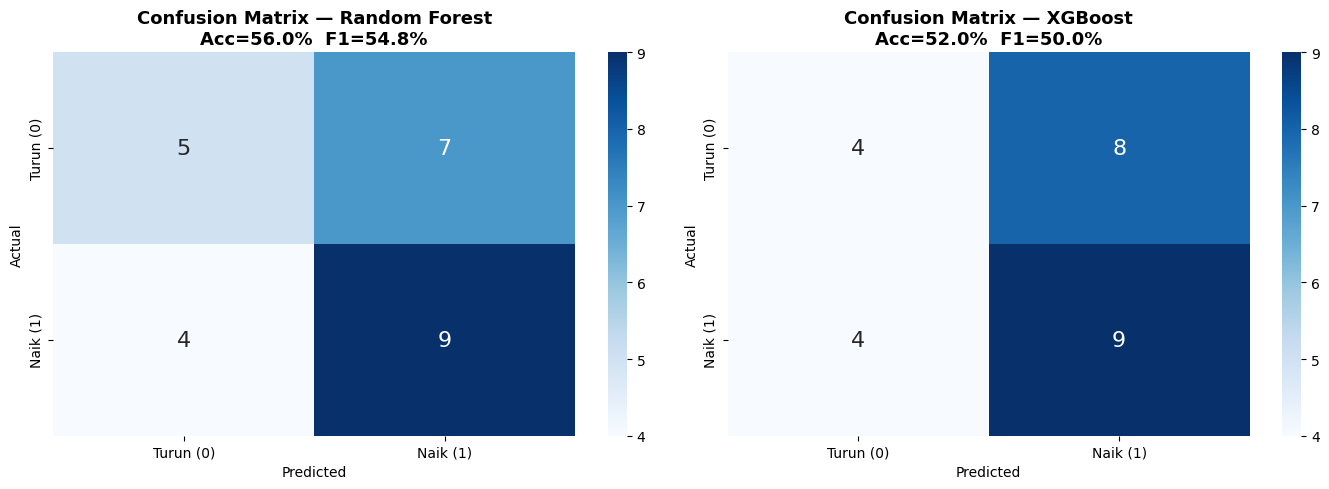

✅ Saved: classification_confusion_matrices.png


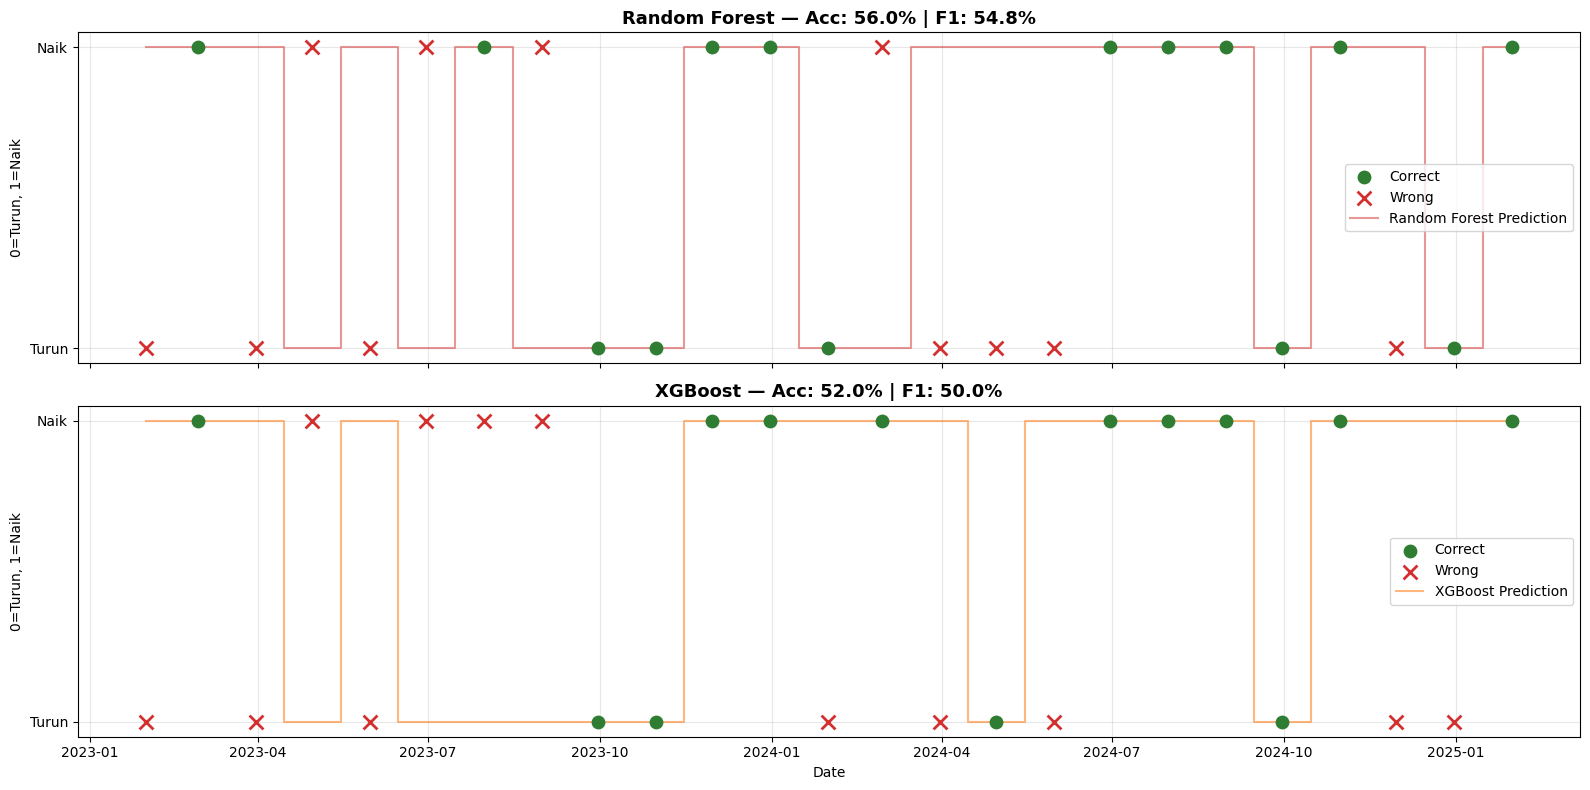

✅ Saved: classification_predictions_timeline.png


In [23]:
# =====================================================
# CELL 8: VISUALIZATIONS
# =====================================================
print("\n" + "=" * 70)
print("CELL 8: VISUALIZATIONS")
print("=" * 70)

# Plot 1: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title, met in [
    (axes[0], rf_cm, 'Random Forest', rf_metrics_dict),
    (axes[1], xgb_cm, 'XGBoost', xgb_metrics_dict),
]:
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                xticklabels=['Turun (0)', 'Naik (1)'],
                yticklabels=['Turun (0)', 'Naik (1)'],
                annot_kws={'size': 16})
    ax.set_title(f'Confusion Matrix — {title}\n'
                 f'Acc={met["Accuracy"]:.1%}  F1={met["F1-Score"]:.1%}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('classification_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_confusion_matrices.png")

# Plot 2: Predictions timeline
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, preds, model_name, color, met in [
    (axes[0], rf_preds, 'Random Forest', COLORS['predicted'], rf_metrics_dict),
    (axes[1], xgb_preds, 'XGBoost', '#FF6F00', xgb_metrics_dict),
]:
    actual_v = target_test.values().flatten()
    pred_v = preds.values().flatten()
    n = min(len(actual_v), len(pred_v))
    dates = target_test.time_index[:n]
    actual_v, pred_v = actual_v[:n], pred_v[:n]
    correct = actual_v == pred_v

    ax.scatter(dates[correct], actual_v[correct], color=COLORS['up'],
               marker='o', s=80, label='Correct', zorder=3)
    ax.scatter(dates[~correct], actual_v[~correct], color=COLORS['down'],
               marker='x', s=100, linewidths=2, label='Wrong', zorder=3)
    ax.step(dates, pred_v, where='mid', color=color, linewidth=1.5,
            alpha=0.5, label=f'{model_name} Prediction')
    ax.set_title(f'{model_name} — Acc: {met["Accuracy"]:.1%} | F1: {met["F1-Score"]:.1%}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('0=Turun, 1=Naik')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Turun', 'Naik'])
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('classification_predictions_timeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_predictions_timeline.png")


CELL 9: SHAP ANALYSIS (Random Forest)
Features (7): ['Direction_lag-1', 'Direction_lag-2', 'Direction_lag-3', 'M2_YoY_lag-1', 'USDIDR_lag-1', 'BI_Rate_lag-1', 'NPL_Ratio_lag-1']
X_train: (93, 7), X_test: (25, 7)

Standalone RF accuracy: 0.5200
Darts RF accuracy:     0.5600
✓ Accuracy consistent

Computing SHAP values...
SHAP values shape: (25, 7)

───────────────────────────────────────────────────────
Feature Importance — Mean |SHAP Value|
───────────────────────────────────────────────────────
  NPL_Ratio_lag-1               : 0.107109 (39.1%)
  USDIDR_lag-1                  : 0.072115 (26.4%)
  Direction_lag-2               : 0.034383 (12.6%)
  M2_YoY_lag-1                  : 0.024543 (9.0%)
  Direction_lag-3               : 0.018558 (6.8%)
  BI_Rate_lag-1                 : 0.008882 (3.2%)
  Direction_lag-1               : 0.008069 (2.9%)

───────────────────────────────────────────────────────
Category Importance (Aggregated)
───────────────────────────────────────────────────────

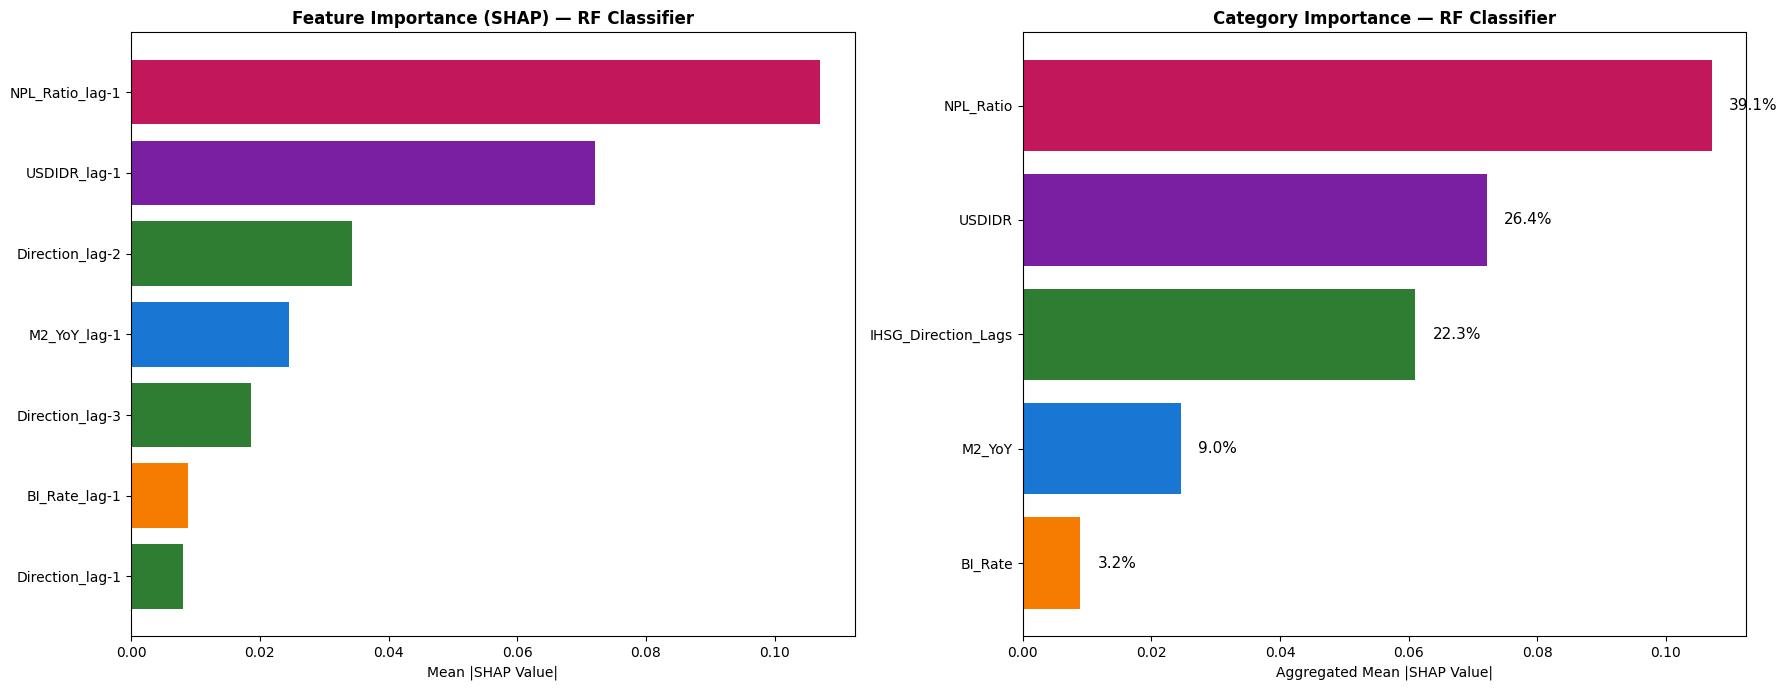

✅ Saved: classification_shap_importance.png


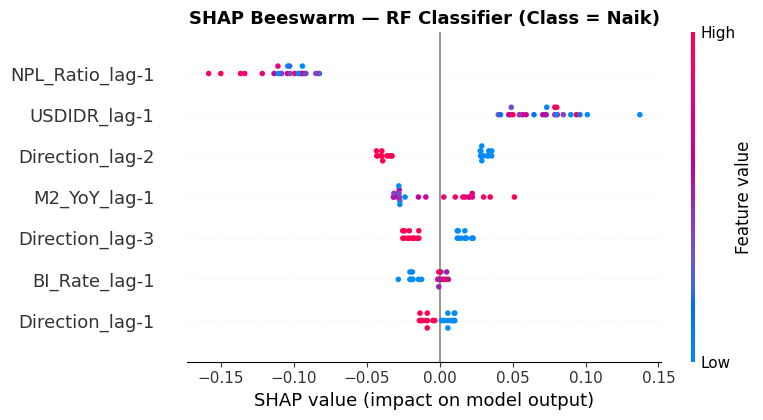

✅ Saved: classification_shap_beeswarm.png
✅ Saved: classification_shap_features.csv, classification_shap_categories.csv


In [24]:
# =====================================================
# CELL 9: SHAP ANALYSIS (Random Forest)
# =====================================================
print("\n" + "=" * 70)
print("CELL 9: SHAP ANALYSIS (Random Forest)")
print("=" * 70)

try:
    lags = rf_params_save['lags']
    lags_cov = rf_params_save['lags_past_covariates']

    target_full = target_series.values().flatten()
    covar_full_vals = covar_full_scaled.values()
    covar_names_list = ['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']

    # Build feature names
    feature_names = []
    for lag in range(1, lags + 1):
        feature_names.append(f'Direction_lag-{lag}')
    for cov_name in covar_names_list:
        for lag in range(1, lags_cov + 1):
            feature_names.append(f'{cov_name}_lag-{lag}')

    start_idx = max(lags, lags_cov)

    # Build feature matrix
    X_all, y_all = [], []
    for t in range(start_idx, len(target_full)):
        row = []
        for lag in range(1, lags + 1):
            row.append(target_full[t - lag])
        for c in range(covar_full_vals.shape[1]):
            for lag in range(1, lags_cov + 1):
                row.append(covar_full_vals[t - lag, c])
        X_all.append(row)
        y_all.append(target_full[t])

    X_all = np.array(X_all)
    y_all = np.array(y_all)

    split_feat = split_point - start_idx
    X_train_shap = X_all[:split_feat]
    X_test_shap = X_all[split_feat:]
    y_train_shap = y_all[:split_feat]
    y_test_shap = y_all[split_feat:]

    print(f"Features ({len(feature_names)}): {feature_names}")
    print(f"X_train: {X_train_shap.shape}, X_test: {X_test_shap.shape}")

    # Train standalone RF with identical best params
    rf_standalone = RandomForestClassifier(
        n_estimators=rf_best_sklearn.n_estimators,
        max_depth=rf_best_sklearn.max_depth,
        max_features=rf_best_sklearn.max_features,
        bootstrap=rf_best_sklearn.bootstrap,
        min_samples_split=rf_best_sklearn.min_samples_split,
        min_samples_leaf=rf_best_sklearn.min_samples_leaf,
        criterion=rf_best_sklearn.criterion,
        random_state=42, n_jobs=-1,
    )
    rf_standalone.fit(X_train_shap, y_train_shap)

    standalone_acc = accuracy_score(y_test_shap, rf_standalone.predict(X_test_shap))
    print(f"\nStandalone RF accuracy: {standalone_acc:.4f}")
    print(f"Darts RF accuracy:     {rf_metrics_dict['Accuracy']:.4f}")
    if abs(standalone_acc - rf_metrics_dict['Accuracy']) > 0.05:
        print("⚠️ Accuracy mismatch > 5%. SHAP may not perfectly represent Darts model.")
    else:
        print("✓ Accuracy consistent")

    # SHAP TreeExplainer
    print("\nComputing SHAP values...")
    explainer = shap.TreeExplainer(rf_standalone)
    shap_values = explainer.shap_values(X_test_shap)

    if isinstance(shap_values, list) and len(shap_values) == 2:
        shap_vals = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_vals = shap_values[:, :, 1]
    else:
        shap_vals = shap_values

    print(f"SHAP values shape: {shap_vals.shape}")

    # Feature importance
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    shap_df = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False)

    total_feat_imp = shap_df['Mean_Abs_SHAP'].sum()
    print(f"\n{'─' * 55}")
    print("Feature Importance — Mean |SHAP Value|")
    print(f"{'─' * 55}")
    for _, row in shap_df.iterrows():
        pct = row['Mean_Abs_SHAP'] / total_feat_imp * 100
        print(f"  {row['Feature']:30s}: {row['Mean_Abs_SHAP']:.6f} ({pct:.1f}%)")

    # Category aggregation
    def get_category(feat):
        if 'Direction' in feat: return 'IHSG_Direction_Lags'
        elif 'M2_YoY' in feat: return 'M2_YoY'
        elif 'USDIDR' in feat: return 'USDIDR'
        elif 'BI_Rate' in feat: return 'BI_Rate'
        elif 'NPL' in feat: return 'NPL_Ratio'
        return 'Other'

    shap_df['Category'] = shap_df['Feature'].apply(get_category)
    cat_importance = shap_df.groupby('Category')['Mean_Abs_SHAP'].sum().sort_values(ascending=False)
    total_cat = cat_importance.sum()

    print(f"\n{'─' * 55}")
    print("Category Importance (Aggregated)")
    print(f"{'─' * 55}")
    for cat, imp in cat_importance.items():
        n_f = len(shap_df[shap_df['Category'] == cat])
        print(f"  {cat:25s}: {imp:.6f} ({imp/total_cat*100:.1f}%) [{n_f} feature(s)]")

    # Plots
    cat_colors = {
        'IHSG_Direction_Lags': COLORS['IHSG'], 'M2_YoY': COLORS['M2_YoY'],
        'USDIDR': COLORS['USDIDR'], 'BI_Rate': COLORS['BI_Rate'],
        'NPL_Ratio': COLORS['NPL_Ratio'], 'Other': '#666666',
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sp = shap_df.sort_values('Mean_Abs_SHAP', ascending=True)
    bar_c = [cat_colors.get(get_category(f), '#666') for f in sp['Feature']]
    axes[0].barh(sp['Feature'], sp['Mean_Abs_SHAP'], color=bar_c)
    axes[0].set_title('Feature Importance (SHAP) — RF Classifier', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Mean |SHAP Value|')

    cp = cat_importance.sort_values(ascending=True)
    cc = [cat_colors.get(c, '#666') for c in cp.index]
    axes[1].barh(cp.index, cp.values, color=cc)
    for i, (cat, val) in enumerate(cp.items()):
        axes[1].text(val + total_cat * 0.01, i, f'{val/total_cat*100:.1f}%', va='center', fontsize=11)
    axes[1].set_title('Category Importance — RF Classifier', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Aggregated Mean |SHAP Value|')

    plt.tight_layout()
    plt.savefig('classification_shap_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: classification_shap_importance.png")

    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_test_shap, feature_names=feature_names, show=False)
    plt.title('SHAP Beeswarm — RF Classifier (Class = Naik)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('classification_shap_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: classification_shap_beeswarm.png")

    shap_df.to_csv('classification_shap_features.csv', index=False)
    cat_importance.to_csv('classification_shap_categories.csv')
    print("✅ Saved: classification_shap_features.csv, classification_shap_categories.csv")

except Exception as e:
    print(f"⚠️ SHAP analysis error: {e}")
    import traceback
    traceback.print_exc()


In [26]:
n_up = int(df_model['IHSG_Direction'].sum())
n_down = len(df_model) - n_up

In [27]:
# =====================================================
# CELL 10: SUMMARY REPORT
# =====================================================
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

best_model_name = 'Random Forest' if rf_metrics_dict['F1-Score'] >= xgb_metrics_dict['F1-Score'] else 'XGBoost'

print(f"""
{'=' * 60}
KLASIFIKASI ARAH IHSG — MODEL 1 (BULANAN, MAKROEKONOMI)
{'=' * 60}

📊 DATA
   Periode        : {df_model['Date'].min().strftime('%B %Y')} — {df_model['Date'].max().strftime('%B %Y')}
   Observasi      : {len(df_model)} bulan
   Train/Test     : {len(target_train)}/{len(target_test)} ({len(target_train)/len(df_model)*100:.0f}%/{len(target_test)/len(df_model)*100:.0f}%)
   Target         : Arah IHSG (1=Naik, 0=Turun)
   Distribusi     : Naik {n_up} ({n_up/len(df_model)*100:.1f}%) / Turun {n_down} ({n_down/len(df_model)*100:.1f}%)

📈 COVARIATES (4 variabel, Inflation dropped)
   1. M2_YoY      — Money Supply Growth YoY
   2. USDIDR      — USD/IDR Exchange Rate
   3. BI_Rate     — BI Interest Rate
   4. NPL_Ratio   — Non-Performing Loan Ratio

⚙️ METHODOLOGY
   Framework      : Darts (SKLearnClassifierModel, XGBClassifierModel)
   Approach       : Lag Direction + Lag Covariates
   GridSearch     : Darts native, n_random_samples=200
   Forecast       : 1-step-ahead via historical_forecasts()
   Evaluation     : backtest() with accuracy, precision, recall, f1
   Scaling        : MinMaxScaler(-1,1) on covariates only
   SHAP           : TreeExplainer (standalone RF, params verified)

🤖 RANDOM FOREST CLASSIFIER
   Accuracy       : {rf_metrics_dict['Accuracy']:.4f} ({rf_metrics_dict['Accuracy']*100:.1f}%)
   Precision      : {rf_metrics_dict['Precision']:.4f}
   Recall         : {rf_metrics_dict['Recall']:.4f}
   F1-Score       : {rf_metrics_dict['F1-Score']:.4f}
   lags={rf_params_save['lags']}, lags_cov={rf_params_save['lags_past_covariates']}
   n_estimators={rf_params_save['n_estimators']}, max_depth={rf_params_save['max_depth']}
   max_features={rf_params_save['max_features']}, bootstrap={rf_params_save['bootstrap']}
   criterion={rf_params_save['criterion']}

🤖 XGBOOST CLASSIFIER
   Accuracy       : {xgb_metrics_dict['Accuracy']:.4f} ({xgb_metrics_dict['Accuracy']*100:.1f}%)
   Precision      : {xgb_metrics_dict['Precision']:.4f}
   Recall         : {xgb_metrics_dict['Recall']:.4f}
   F1-Score       : {xgb_metrics_dict['F1-Score']:.4f}
   {', '.join(f'{k}={v}' for k,v in best_xgb_params.items())}

🏆 BEST MODEL: {best_model_name}

📁 OUTPUT FILES
   classification_eda.png
   classification_confusion_matrices.png
   classification_predictions_timeline.png
   classification_shap_importance.png
   classification_shap_beeswarm.png
   classification_shap_features.csv
   classification_shap_categories.csv
   rf_classifier_best_params.json
   xgb_classifier_best_params.json
""")

print(f"{'=' * 60}")
print("COMPLETE!")
print(f"{'=' * 60}")


FINAL SUMMARY

KLASIFIKASI ARAH IHSG — MODEL 1 (BULANAN, MAKROEKONOMI)

📊 DATA
   Periode        : January 2015 — January 2025
   Observasi      : 121 bulan
   Train/Test     : 96/25 (79%/21%)
   Target         : Arah IHSG (1=Naik, 0=Turun)
   Distribusi     : Naik 71 (58.7%) / Turun 50 (41.3%)

📈 COVARIATES (4 variabel, Inflation dropped)
   1. M2_YoY      — Money Supply Growth YoY
   2. USDIDR      — USD/IDR Exchange Rate
   3. BI_Rate     — BI Interest Rate
   4. NPL_Ratio   — Non-Performing Loan Ratio

⚙️ METHODOLOGY
   Framework      : Darts (SKLearnClassifierModel, XGBClassifierModel)
   Approach       : Lag Direction + Lag Covariates
   GridSearch     : Darts native, n_random_samples=200
   Forecast       : 1-step-ahead via historical_forecasts()
   Evaluation     : backtest() with accuracy, precision, recall, f1
   Scaling        : MinMaxScaler(-1,1) on covariates only
   SHAP           : TreeExplainer (standalone RF, params verified)

🤖 RANDOM FOREST CLASSIFIER
   Accuracy   